In [1]:
import os
import sys
import time
import json
import random
import argparse
from pathlib import Path

import torch

# Repo setup
repo_root = "/scratch/jq2uw/MME/instruct_vlm_edit"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.append(repo_root)

from argparse import Namespace
from pathlib import Path
import torch 

from revlm.config_utils import configure_args
from revlm.run.edit import run_edit

editor_name = "ike_chain"
# === Change this to test different samples ===
example_idx = 0


In [2]:
# Project root
project_root = Path("/scratch/jq2uw/MME/instruct_vlm_edit")

# Build test paths from args (no hardcoding)
args = Namespace(
    config="revlm/config/config.yaml",
    editor=editor_name,
    model_name="qwen3_4b",
    dataset_name="aokvqa",
    task="mc",
    batch_size=1,
    split="all",
    rationale=False,
    cot=False,
    subsample=5,  # small for testing
    overwrite=True,
)

args.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
config = configure_args(args, config_path=args.config)
config.subsample = args.subsample


Task evaluation metrics will be saved to results/te/ike_chain/Qwen3-VL-4B-Instruct/aokvqa
Edit evaluation metrics will be saved to results/ee/ike_chain/Qwen3-VL-4B-Instruct/aokvqa
Predictions will be saved to results/pred/Qwen3-VL-4B-Instruct/aokvqa
Post-edit predictions will be saved to results/pred_postedit/ike_chain/Qwen3-VL-4B-Instruct/aokvqa
Unified filename to save: mc_all_sub5.json


## Step 2: Load Model & Editor


In [3]:
from revlm.models import VQAModel
from revlm.editors import IKE_CHAIN
from revlm.dataset.datasets import VQADataset

# Load model
vlm = VQAModel(config)
print(f"Model loaded: {type(vlm.model).__name__}")

# Load editor
editor = IKE_CHAIN(config, vlm)


# Load dataset
edit_ds = VQADataset(config)
edit_ds.set_dataloader()

# Ensure specific UIDs are included
required_uids = {'9780'}  # Add UIDs you want to include here
required_samples = [ex for ex in edit_ds.data if ex.get("uid") in required_uids]
other_samples = [ex for ex in edit_ds.data if ex.get("uid") not in required_uids]

if config.subsample and len(edit_ds) > config.subsample:
    n_others = max(0, config.subsample - len(required_samples))
    edit_ds.data = required_samples + random.sample(other_samples, min(n_others, len(other_samples)))
print(f"Dataset: {len(edit_ds.data)} samples (required UIDs: {[ex.get('uid') for ex in required_samples]})")


Model loaded: Qwen3VLForConditionalGeneration
Dataset: 5 samples (required UIDs: ['9780'])


## Step 3-4: Visualize Augmentation and Patchification


Question: What material is used to make the stick on the woman's shoulder?
Answer: bamboo
COT: The image shows a woman with a stick on her shoulder. The stick appears firm but flexible. Bamboo is a type of wood that is firm and flexible. Bamboo grows commonly in Asian regions....

s1: The image shows a woman with a stick on her shoulder.
[Augmenter] Loading Qwen/Qwen2.5-1.5B-Instruct...


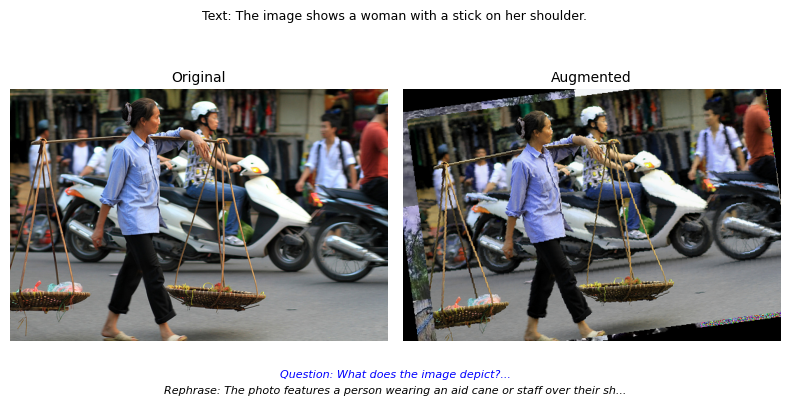

[VQA] Q: Does the image show the image shows a woman with a stick on her shoulder?
[Passed p_yes>0.5]: 4 patches
[Route1 - Smallest unit (1) → best NLL]: ['1x1_1']
[Route2 - Best NLL]: ['2x1_1']
[Selected]: 2 patches


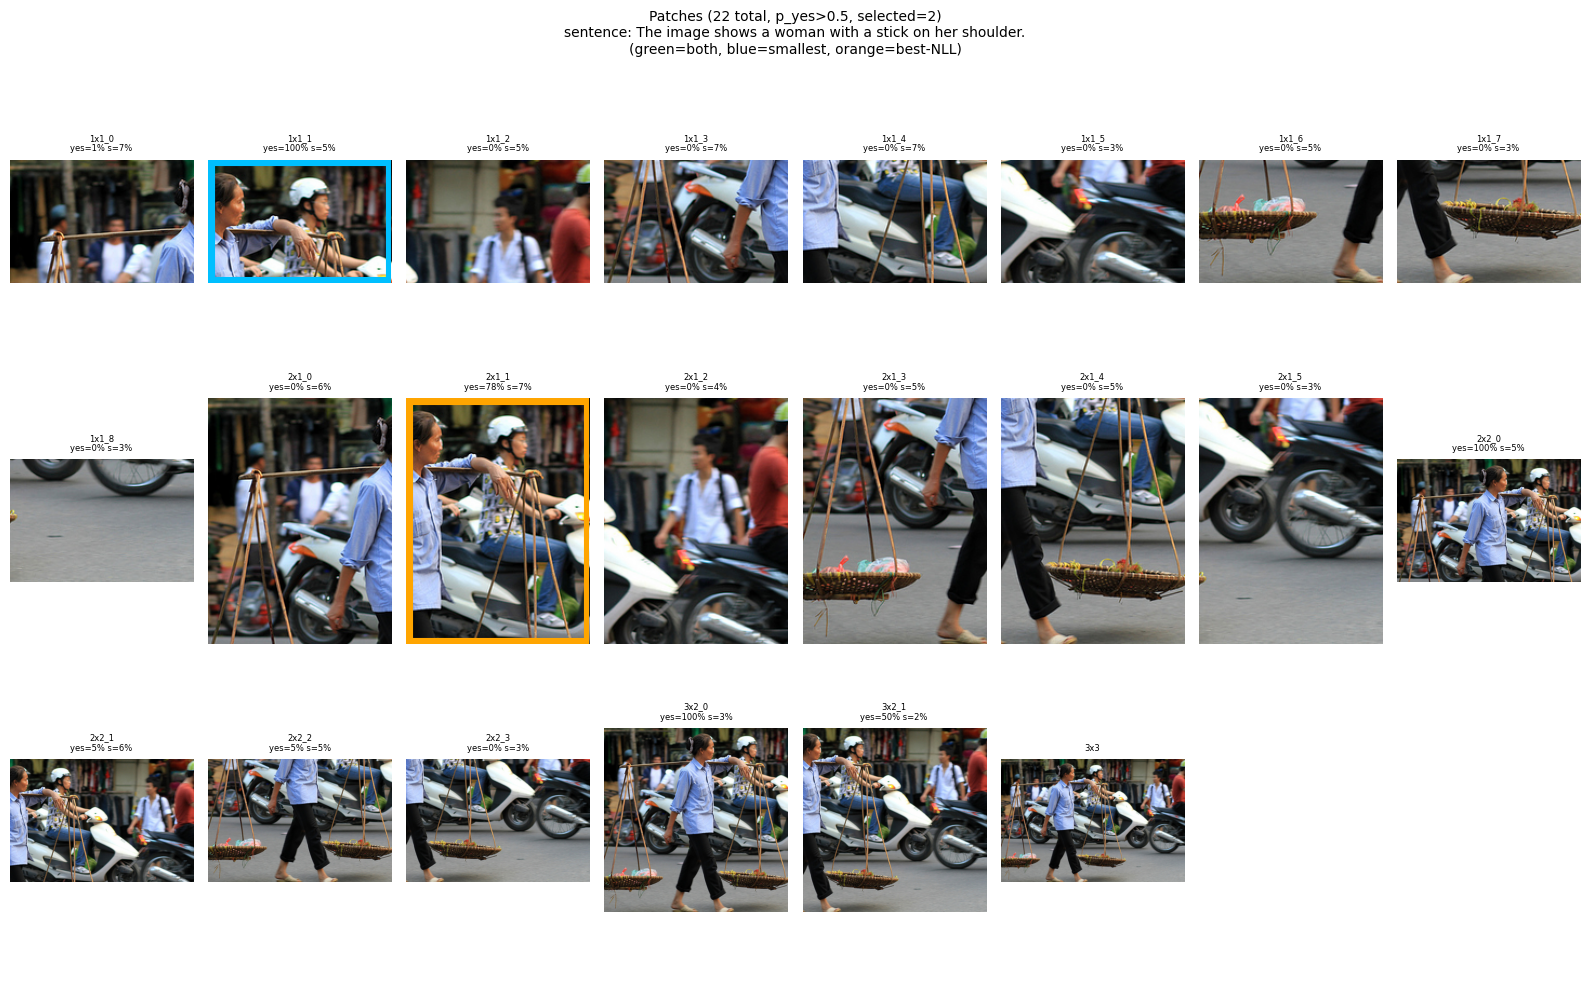

[VQA] Q: Does the image show the stick appears firm but flexible?
[Passed p_yes>0.5]: 16 patches
[Route1 - Smallest unit (1) → best NLL]: ['1x1_4']
[Route2 - Best NLL]: ['1x1_4']
[Selected]: 1 patches


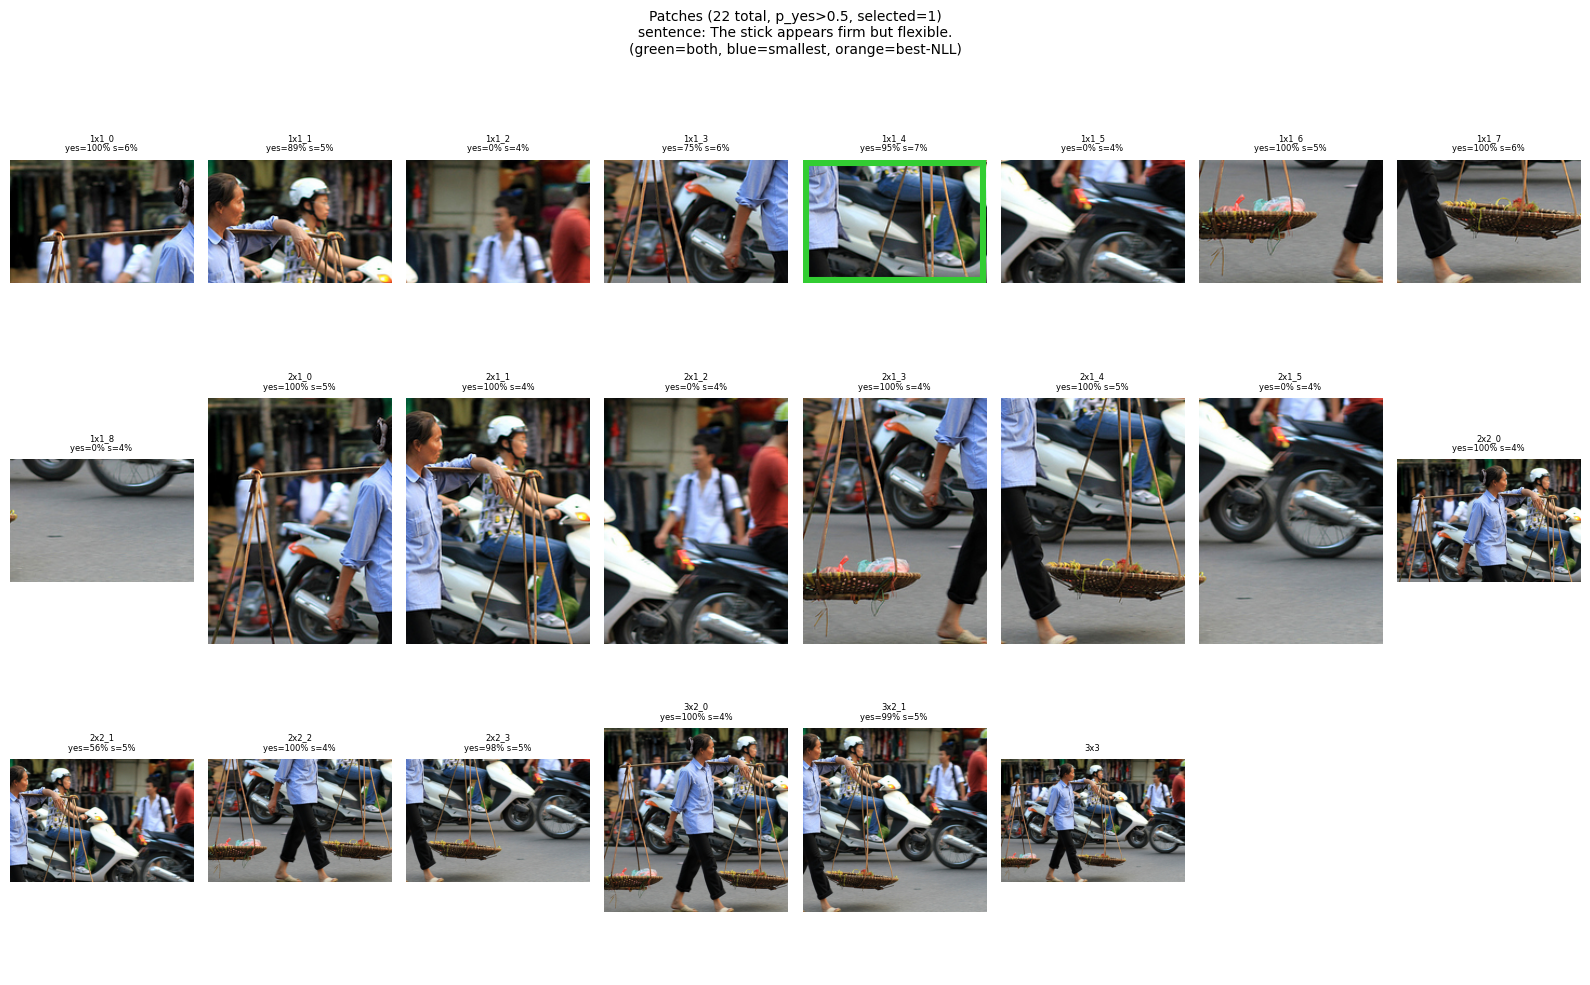

[VQA] Q: Does the image show bamboo is a type of wood that is firm and flexible?
[Passed p_yes>0.5]: 16 patches
[Route1 - Smallest unit (1) → best NLL]: ['1x1_1']
[Route2 - Best NLL]: ['1x1_1']
[Selected]: 1 patches


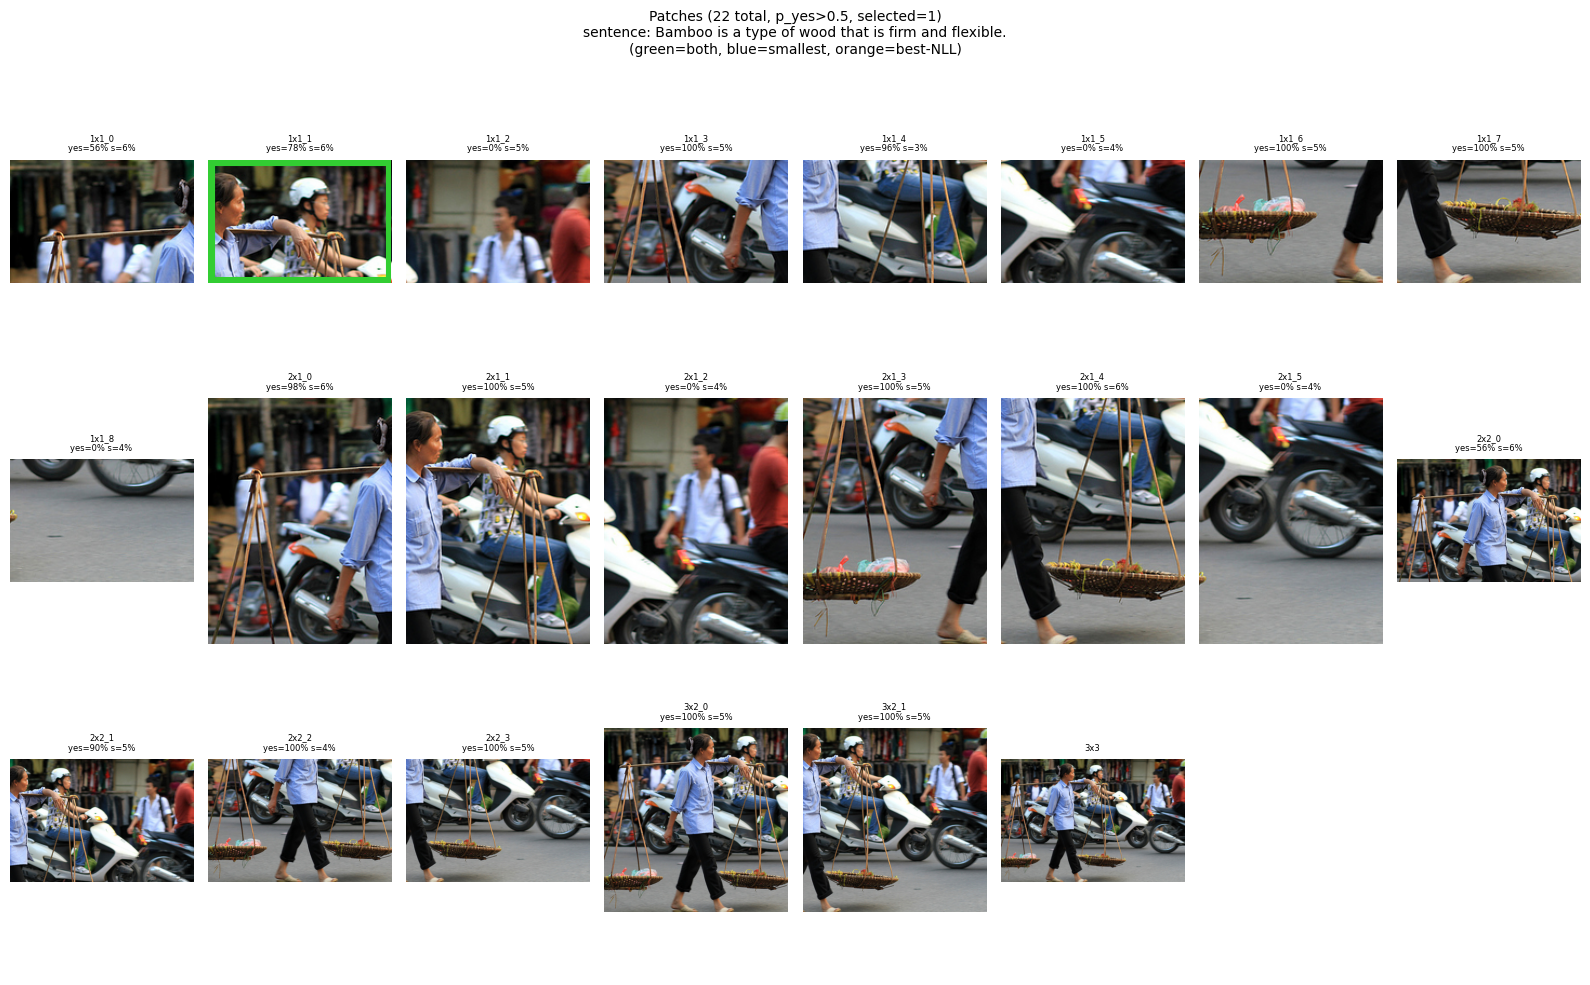

[VQA] Q: Does the image show bamboo grows commonly in asian regions?
[Passed p_yes>0.5]: 17 patches
[Route1 - Smallest unit (1) → best NLL]: ['1x1_1']
[Route2 - Best NLL]: ['2x1_2']
[Selected]: 2 patches


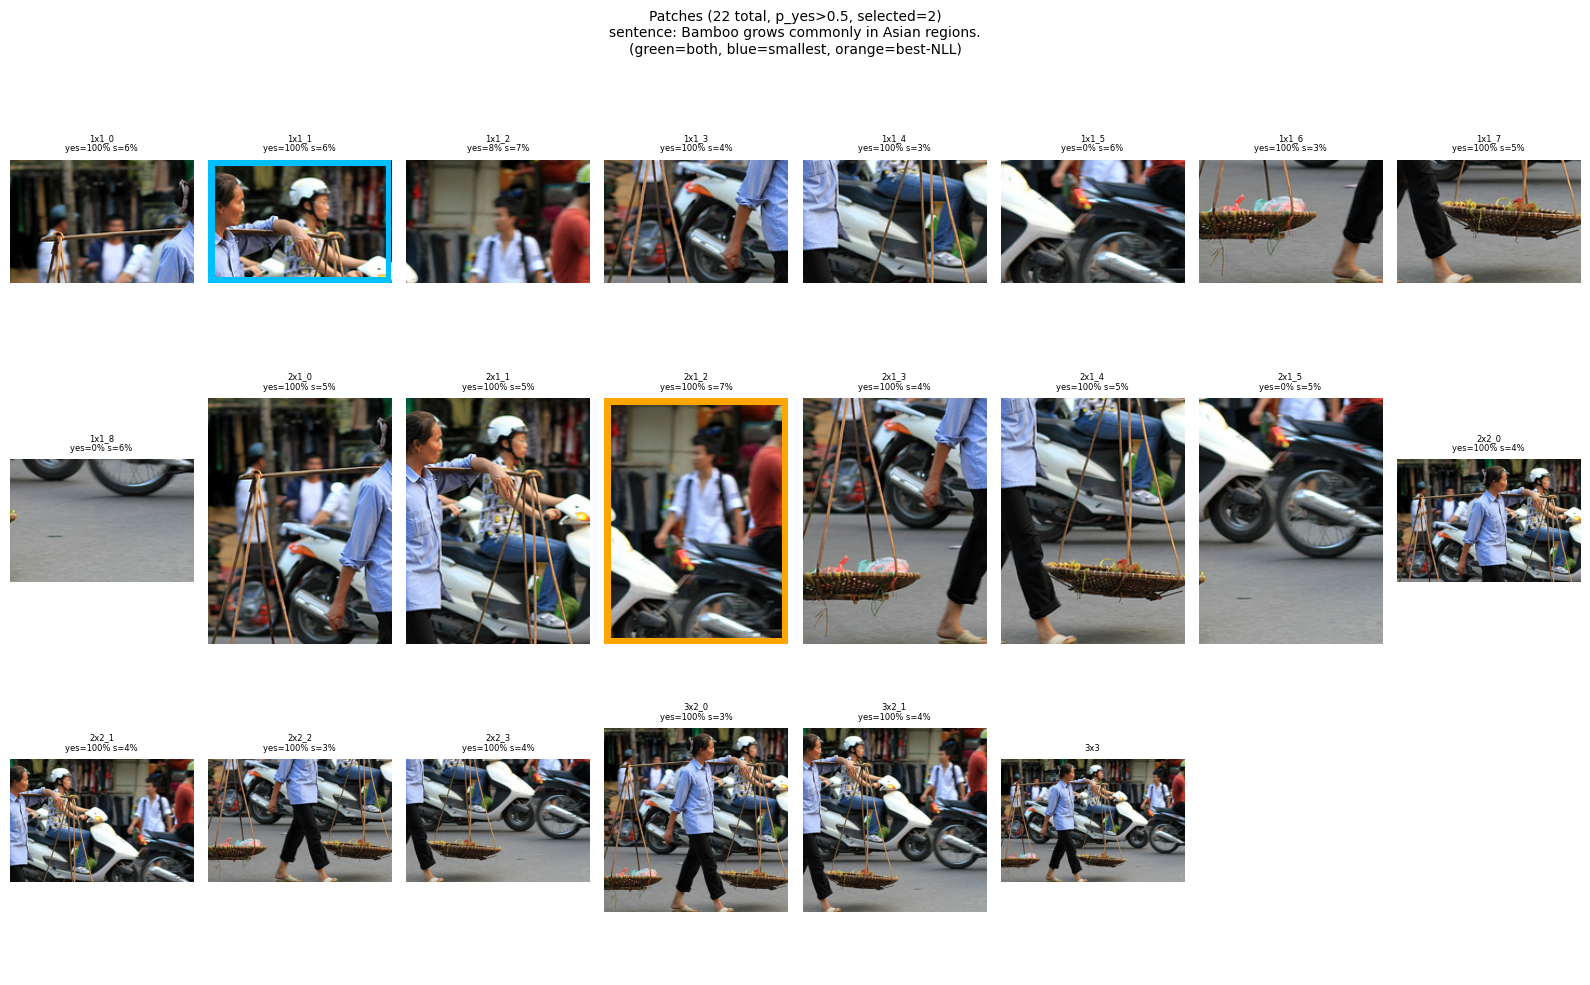

In [4]:
# Pick a sample
ex = edit_ds.data[example_idx]
print(f"Question: {ex['question']}")
print(f"Answer: {ex.get('answer', ex.get('target', ''))}")
print(f"COT: {ex.get('cot', ex.get('rationale', ''))[:200]}...")

# Get first sentence (s1)
import re
cot = ex.get('cot') or ex.get('rationale') or ''
sents = [s.strip() for s in re.split(r"(?<=[.!?])\s+", cot.strip()) if s.strip()]
s1 = sents[0] if sents else ""
print(f"\ns1: {s1}")

# Visualize augmentation (mosaic background + transforms)
editor.augmenter.visualize(ex['image'], text=s1, use_mosaic=True)

# Visualize patches (highlights top-k selected by s1 likelihood)
for s in sents:
    editor.visualize_patches(ex['image'], sentence=s)


## Step 5: Add Edits to Codebook

In [5]:
# Add edits to codebook
editor.edit(config, edit_ds=edit_ds)

# View stats
stats = editor.get_stats()
print("\nCodebook Stats:")
for k, v in stats.items():
    print(f"  {k}: {v}")


[IKE_CHAIN] mode=dual_sbert, pool=mean, pair_rationale_w=both, merge=True, aug_as_keys=False
[IKE_CHAIN] edit 1/5...[Keys] +11 added, 0 merged (from 11 candidates)
[IKE_CHAIN] edit 2/5...[Keys] +8 added, 0 merged (from 8 candidates)
[IKE_CHAIN] edit 3/5...[Keys] +4 added, 3 merged (from 7 candidates)
[IKE_CHAIN] edit 4/5...[Keys] +4 added, 5 merged (from 9 candidates)
[IKE_CHAIN] edit 5/5...[Keys] +8 added, 0 merged (from 8 candidates)
[IKE_CHAIN] +5 edits (p_yes>0.5, augment(area=0.9)), 0->35 keys, 0.1 MB

Codebook Stats:
  num_keys: 35
  num_orig_keys: 21
  num_patch_keys: 14
  num_merged_keys: 5
  num_question_keys: 5
  num_rationale_keys: 30
  num_aug_keys: 0
  num_edits: 5
  p_yes_threshold: 0.5
  merge_keys: True
  cap_edits: 0
  cap_keys: 5
  aug_as_keys: False
  emb_size_mb: 0.11962890625
  avg_radius: 172.98239135742188
  min_radius: 88.03337860107422
  max_radius: 260.3634948730469


## Step 6: Visualize Codebook Network


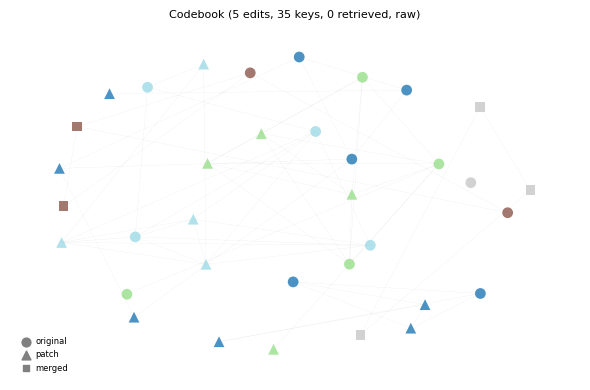

[Hubness] computed sigma for 35 keys (k=30, median=304.59)
[Reject] threshold=0.94 (p25 of 595 pairs, hubness=True)
[Hubness correction] enabled, scaling distances by σ_k


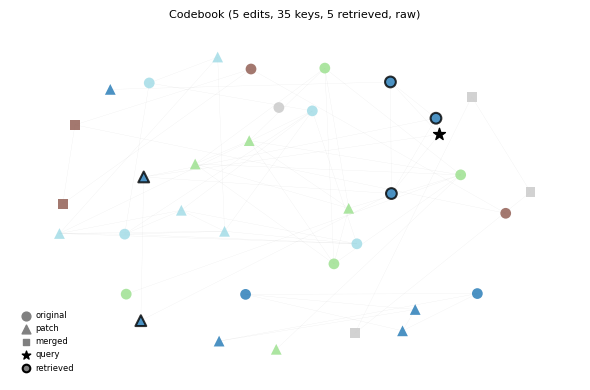

In [6]:
# Plot codebook network (color by edit, size by original vs patch)
editor.plot_codebook()

# Plot with a query point
test_ex = edit_ds.data[example_idx]
editor.plot_codebook(query_img=test_ex['image'], query_text=test_ex['question'])


## Step 7: Test Retrieval


In [7]:
# Test retrieval on training sample (should retrieve)
ex = edit_ds.data[example_idx]
facts = editor._retrieve(ex['image'], ex['question'])
print(f"Query: {ex['question']}")
print(f"Retrieved {len(facts)} facts:")
for i, f in enumerate(facts):
    print(f"  [{i}] {f[:100]}...")


Query: What material is used to make the stick on the woman's shoulder?
Retrieved 3 facts:
  [0] The image shows a woman with a stick on her shoulder....
  [1] The answer to 'What material is used to make the stick on the woman's shoulder?' is bamboo....
  [2] The stick appears firm but flexible....


## Step 8: Generate with Retrieved Context


In [8]:
# Apply to dataset (prepends retrieved facts to prompts)
editor.apply_to_dataset(edit_ds)

# Check augmented prompt
ex = edit_ds.data[example_idx]
print(f"Original prompt: {ex.get('prompt_orig', 'N/A')}")
print(f"Human rationale: {ex.get('rationale', 'N/A')}")
print(f"proxy Human COT: {ex.get('cot', 'N/A')}")
print(f"Augmented prompt: {ex['prompt']}")

# Generate answer
answer = vlm.generate([ex['image']], [ex['prompt']], max_new_tokens=64)
print(f"\nGenerated: {answer[0]}")
print(f"Gold: {ex.get('gold', {}).get('label', '')}")


[IKE_CHAIN] applied facts to 5/5 examples
Original prompt: What material is used to make the stick on the woman's shoulder?
Human rationale: It is a firm but flexible asian wood. it grows commonly where she lives.
proxy Human COT: The image shows a woman with a stick on her shoulder. The stick appears firm but flexible. Bamboo is a type of wood that is firm and flexible. Bamboo grows commonly in Asian regions.
Augmented prompt: The image shows a woman with a stick on her shoulder. The answer to 'What material is used to make the stick on the woman's shoulder?' is bamboo. The stick appears firm but flexible. What material is used to make the stick on the woman's shoulder?

Generated: The stick on the woman’s shoulder is made of **bamboo**.This is evident from the stick’s appearance it is firm yet flexible, with a natural, segmented texture and light brown color typical of bamboo poles. In many Southeast Asian cultures, bamboo is commonly used to construct traditional carrying poles or “

## Step 9: Test with Generality Evaluation Samples


In [9]:
# Load generality evaluation data for ALL samples (run once)
from revlm.metrics.utils.t_gen import get_t_gen_input
from revlm.metrics.utils.i_gen import get_i_gen_input
from revlm.metrics.utils.r_gen import get_r_gen_input
from PIL import Image

dataset_name = config.experiment.dataset_name

related_texts = get_t_gen_input(dataset_name, edit_ds)
related_images = get_i_gen_input(dataset_name, edit_ds)
related_r_gen_df = get_r_gen_input(dataset_name, edit_ds)

print(f"Loaded generality data for {len(edit_ds.data)} samples")
print(f"Text gen UIDs: {len(related_texts)}, Image gen UIDs: {len(related_images)}, Rationale gen rows: {len(related_r_gen_df)}")


[r_gen] Loaded: 132119 rows, 18181 uids
[r_gen] After bad_sids filter: 118652 rows, 18147 uids (removed 13467)
[r_gen] After edit_ds filter: 28 rows, 5 uids
Loaded generality data for 5 samples
Text gen UIDs: 5, Image gen UIDs: 5, Rationale gen rows: 28


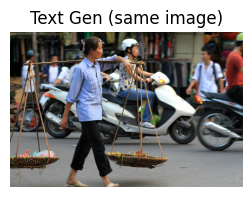

[example_idx=0] Original Q: What material is used to make the stick on the woman's shoulder?
Paraphrased Q: What type of material is the stick on the woman's shoulder made from?
Retrieved 3 facts:
  [0] The image shows a woman with a stick on her shoulder....
  [1] The answer to 'What material is used to make the stick on the woman's shoulder?' is bamboo....
  [2] The stick appears firm but flexible....


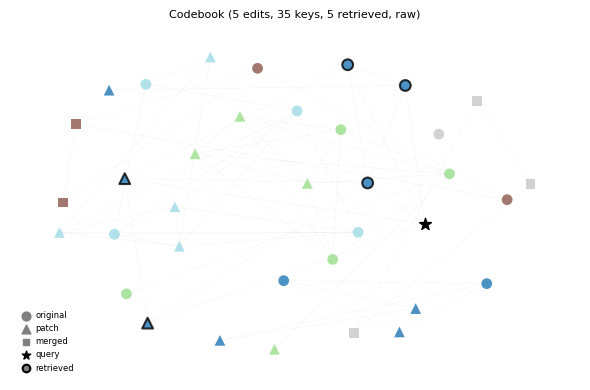

In [10]:
# =============================================

# Text Generality: same image, paraphrased question
import matplotlib.pyplot as plt
ex = edit_ds.data[example_idx]
uid = str(ex["uid"])
if uid in related_texts:
    t_gen_q = related_texts[uid][0]
    img = ex["image"] if isinstance(ex["image"], Image.Image) else Image.open(ex["image"]).convert("RGB")
    plt.figure(figsize=(3,3)); plt.imshow(img); plt.axis('off'); plt.title("Text Gen (same image)"); plt.show()
    print(f"[example_idx={example_idx}] Original Q: {ex['question']}")
    print(f"Paraphrased Q: {t_gen_q}")
    facts = editor._retrieve(img, t_gen_q)
    print(f"Retrieved {len(facts)} facts:")
    for i, f in enumerate(facts):
        print(f"  [{i}] {f[:100]}...")
    editor.plot_codebook(query_img=img, query_text=t_gen_q)
else:
    print(f"No text generality data for uid={uid}")


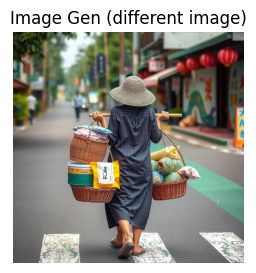

Question: What material is used to make the stick on the woman's shoulder?
Image: data/related_image/aokvqa/train_44065/flux_0.png
Retrieved 3 facts:
  [0] The image shows a woman with a stick on her shoulder....
  [1] The answer to 'What material is used to make the stick on the woman's shoulder?' is bamboo....
  [2] The stick appears firm but flexible....


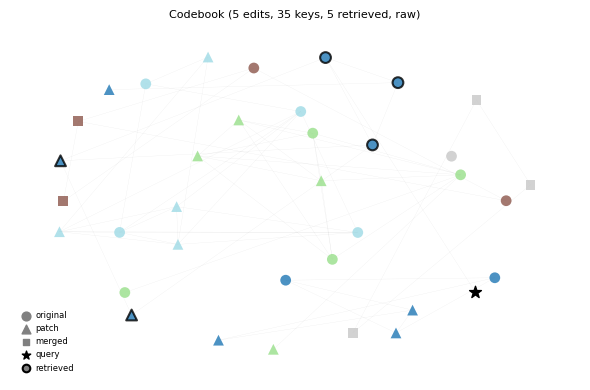

In [11]:
# Image Generality: same question, different image
ex = edit_ds.data[example_idx]
uid = str(ex["uid"])
if uid in related_images:
    i_gen_img = Image.open(related_images[uid][0]).convert("RGB")
    plt.figure(figsize=(3,3)); plt.imshow(i_gen_img); plt.axis('off'); plt.title("Image Gen (different image)"); plt.show()
    print(f"Question: {ex['question']}")
    print(f"Image: {related_images[uid][0]}")
    facts = editor._retrieve(i_gen_img, ex["question"])
    print(f"Retrieved {len(facts)} facts:")
    for i, f in enumerate(facts):
        print(f"  [{i}] {f[:100]}...")
    editor.plot_codebook(query_img=i_gen_img, query_text=ex["question"])
else:
    print(f"No image generality data for uid={uid}")


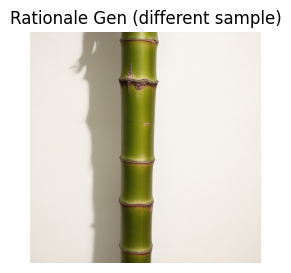

Question: What type of wood is firm and flexible?
Image: data/r_gen/image/aokvqa/9780_6.png
Retrieved 2 facts:
  [0] Bamboo is a type of wood that is firm and flexible....
  [1] Bamboo grows commonly in Asian regions....


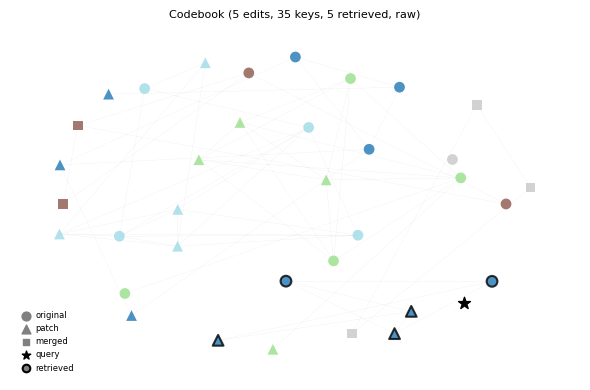

In [12]:

# Rationale Generality: different sample from same edit
ex = edit_ds.data[example_idx]
uid = str(ex["uid"])
r_gen_for_uid = related_r_gen_df[related_r_gen_df["uid"] == uid]
if len(r_gen_for_uid) > 0:
    row = r_gen_for_uid.iloc[5]
    # row['question'] = "Does the image show a spindle and a cordless phone?"
    r_gen_img = Image.open(row["image_path"]).convert("RGB")
    plt.figure(figsize=(3,3)); plt.imshow(r_gen_img); plt.axis('off'); plt.title("Rationale Gen (different sample)"); plt.show()
    print(f"Question: {row['question']}")
    print(f"Image: {row['image_path']}")
    facts = editor._retrieve(r_gen_img, row["question"])
    print(f"Retrieved {len(facts)} facts:")
    for i, f in enumerate(facts):
        print(f"  [{i}] {f[:100]}...")
    editor.plot_codebook(query_img=r_gen_img, query_text=row["question"])
else:
    print(f"No rationale generality data for uid={uid}")
